In [33]:
import os
from dotenv import load_dotenv
from getpass import getpass
import json
from meshapi import MeshAPI, MeshAPIError

In [3]:
MESH_API_BASE_URL = os.getenv("MESHAPI_BASE_URL", "https://api.meshapi.ai")
MESH_TOKEN = os.getenv("MESH_API_KEY")

client = MeshAPI(base_url=MESH_API_BASE_URL, token=MESH_TOKEN)
RAWHEADERS =  {"Authorization": f"Bearer {MESH_TOKEN}", "Content-Type": "application/json"}

def show(obj, indent=2):
    if hasattr(obj, "model_dump_json"):
        print(obj.model_dump_json(indent=indent))
    else:
        print(json.dumps(obj, indent=indent, default=str))
print("Client ready")

Client ready


In [4]:
FAST_MODEL = "openai/gpt-4o-mini"
SMART_MODEL = "mistral/mistral-large-3-675b-instruct"

print("FAST_MODEL  =", FAST_MODEL)
print("SMART_MODEL =", SMART_MODEL)

FAST_MODEL  = openai/gpt-4o-mini
SMART_MODEL = mistral/mistral-large-3-675b-instruct


In [6]:
from meshapi import ChatCompletionParams, ChatMessage 

resp = client.chat.completions.create(
    ChatCompletionParams(
        model=FAST_MODEL,
        
        messages=[
            ChatMessage(
                role="user",
                content="In one sentence, explain what is LLM gateway ?"
            )
        ],
        max_tokens=60,
    )
)

In [7]:
print(resp.choices[0].message.content)

An LLM gateway is a system that facilitates access to large language models (LLMs) by managing requests, responses, and integration with various applications or services.


In [8]:
# Streaming

for chunk in client.chat.completions.stream(
    ChatCompletionParams(
        model=FAST_MODEL,
        messages=[
            ChatMessage(
                role="user",
                content="Count from 1 to 5"
            )
        ]
    )
):
    if chunk.choices and chunk.choices[0].delta and chunk.choices[0].delta.content:
        print(chunk.choices[0].delta.content, end="", flush=True)

1, 2, 3, 4, 5.

In [10]:
#Tool calling
from meshapi import Tool, ToolFunction 

WEATHER_TOOL = Tool(
    type="function",
    function=ToolFunction(
        name="get_weather",
        description="Get current weather for a city",
        parameters={
            "type": "object", "properties":{"city":{"type":"string"}}, "required":["city"]
        },
    ),
)

resp = client.chat.completions.create(
    ChatCompletionParams(
        model=FAST_MODEL,
        messages=[ChatMessage(role="user", content="What is weather in Delhi?")],
        tools=[WEATHER_TOOL],
        tool_choice="auto",
        max_tokens=100,
    )
)

call = resp.choices[0].message.tool_calls[0]
print("Model wants to call: ", call.function.name,"with args:", call.function.arguments)

Model wants to call:  get_weather with args: {"city":"Delhi"}


In [16]:
print("Answer: ", resp)

Answer:  id='chatcmpl-EMvr308dhCXUeyaQDLAJtgmxjj0aQ' object='chat.completion' created=1789134317 model='gpt-4o-mini-2024-07-18' choices=[ChatCompletionChoice(index=0, message=ChatCompletionMessage(role='assistant', content=None, tool_calls=[ToolCall(id='call_aIgxoIPkDP7gDpDzSlSqyXaA', type='function', function=ToolCallFunction(name='get_weather', arguments='{"city":"Delhi"}'), thought_signature=None)], audio=None), finish_reason='tool_calls', logprobs=None)] usage=UsageInfo(prompt_tokens=50, completion_tokens=14, total_tokens=64, prompt_tokens_details={'cached_tokens': 0, 'audio_tokens': 0}, completion_tokens_details={'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}, classifier_prompt_tokens=None, classifier_completion_tokens=None, classifier_tokens=None) system_fingerprint='fp_fa2b8a6d5b'


In [17]:
#Structure Output

from pydantic import BaseModel 

class Country(BaseModel):
    country: str
    capital: str
    population_millions: float
    
resp = client.chat.completions.create(
    ChatCompletionParams(
        model = FAST_MODEL,
        messages=[
            ChatMessage(
                role="user",
                content="Give me fact about India."
            )
        ],
        response_format = {"type":"json_schema", "json_schema":{"name":"Country", "schema":Country.model_json_schema()}},
    )
)

country = Country.model_validate_json(resp.choices[0].message.content)
print(type(country).__name__, "->", country)

print("Country: ", country.country)
print("Capital: ", country.capital)
print("Population: ", country.population_millions)


Country -> country='India' capital='New Delhi' population_millions=1393.0
Country:  India
Capital:  New Delhi
Population:  1393.0


In [21]:
#Compare model
from meshapi import CompareParams

result = client.compare.create(
    CompareParams(
        models = [FAST_MODEL, SMART_MODEL],
        messages=[ChatMessage(role="user", content="In 5 words or less, what is LLM gateway ?")],
    )
)

show(result)

{
  "comparison_id": "cmp_14e464d5b64a18e043cd",
  "object": "compare.completion",
  "created": 1789135098,
  "models": [
    "openai/gpt-4o-mini",
    "mistral/mistral-large-3-675b-instruct"
  ],
  "results": [
    {
      "model": "openai/gpt-4o-mini",
      "response_body": {
        "id": "chatcmpl-EMw3ZwHfLiL5rNFHgjhcnDr1rr8kp",
        "object": "chat.completion",
        "created": 1789135093,
        "model": "gpt-4o-mini-2024-07-18",
        "choices": [
          {
            "index": 0,
            "message": {
              "role": "assistant",
              "content": "Access point for language models.",
              "refusal": null,
              "annotations": []
            },
            "logprobs": null,
            "finish_reason": "stop"
          }
        ],
        "usage": {
          "prompt_tokens": 20,
          "completion_tokens": 6,
          "total_tokens": 26,
          "prompt_tokens_details": {
            "cached_tokens": 0,
            "audio_token

In [ ]:
print(result)

comparison_id='cmp_14e464d5b64a18e043cd' object='compare.completion' created=1789135098 models=['openai/gpt-4o-mini', 'mistral/mistral-large-3-675b-instruct'] results=[ModelCompareResult(model='openai/gpt-4o-mini', response_body={'id': 'chatcmpl-EMw3ZwHfLiL5rNFHgjhcnDr1rr8kp', 'object': 'chat.completion', 'created': 1789135093, 'model': 'gpt-4o-mini-2024-07-18', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': 'Access point for language models.', 'refusal': None, 'annotations': []}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'prompt_tokens': 20, 'completion_tokens': 6, 'total_tokens': 26, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}, 'service_tier': 'default', 'system_fingerprint': 'fp_da56f7d23d'}, content='Access point for language models.', latency_ms=778, error=None, error_code=None, usage=Tok

In [ ]:
#Error Handling


try:

    client.chat.completions.create(

        ChatCompletionParams(model="not-a-real-provider/not-a-real-model", messages=[ChatMessage(role="user", content="hi")])

    )

except MeshAPIError as e:

    print(f"Caught it cleanly -> status={e.status} code={e.error_code}")

    print("message:", str(e))

In [24]:
#Response API

from meshapi import ResponsesParams

r = client.responses.create(ResponsesParams(model=FAST_MODEL, input="Say pong in one word."))

print("status:", r.status)

print("text:", r.output[0]["content"][0]["text"])

status: completed
text: Pong!


In [26]:
from meshapi import RouterSelectParams

choice = client.router.select(RouterSelectParams(messages=[ChatMessage(role="user", content="Write a haiku about the ocean")]))

print("router would pick:", choice.model)



resp = client.chat.completions.create(

    ChatCompletionParams(model="auto", messages=[ChatMessage(role="user", content="What is 12*8? Just the number.")], max_tokens=20)

)

print("actually picked:", resp.model, "-> reply:", resp.choices[0].message.content)

if resp.usage.classifier_tokens:

    print("classifier overhead (tokens):", resp.usage.classifier_tokens, "-- you're billed for this too")

else:

    print("classifier overhead: not reported for this provider/response (field is optional, sometimes None)")


router would pick: meta-llama/llama-4-scout
actually picked: anthropic/claude-haiku-4.5 -> reply: 96
classifier overhead: not reported for this provider/response (field is optional, sometimes None)


In [27]:
#Embedding

from meshapi import EmbeddingsParams

EMBEDDING_MODEL = "openai/text-embedding-3-small"

emb = client.embeddings.create(EmbeddingsParams(model=EMBEDDING_MODEL, input=["hello world"], dimensions=256))
print("vector length:", len(emb.data[0].embedding))
print("first 5 numbers:", emb.data[0].embedding[:5])


vector length: 256
first 5 numbers: [-0.01287841796875, -0.07427978515625, 0.064697265625, 0.054473876953125, -0.047027587890625]


In [28]:
#Built-in RAG
import time

from meshapi import SearchRequest

# One short doc produces exactly one chunk (MeshAPI's chunker has a size floor well above a
# single sentence), so top_k=3 against one file just repeats the same chunk. Ten small, distinct
# documents give top_k=3 three genuinely different results instead.
#
# We also explicitly scope search to file_ids=our own upload ids. MeshAPI's RAG file store is
# account-wide with no delete endpoint -- every file ever uploaded with this key (other test runs,
# other apps) stays searchable forever, so an unscoped search can return unrelated pollution.
DOCS = {
    "refund.txt": "Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.",
    "storage.txt": "Storage Limits: The Starter plan includes 100GB of storage, Pro includes 2TB, and Enterprise is negotiated per contract. Exceeding your plan's limit pauses new uploads until you upgrade.",
    "retention.txt": "Data Retention: Deleted files move to a Trash folder and are permanently removed after 30 days. Account cancellation triggers a 90-day data retention window before permanent deletion.",
    "sharing.txt": "Sharing and Permissions: Files can be shared via link or invited by email with role-based permissions -- Viewer, Commenter, Editor, Owner. Shared links can be password-protected.",
    "2fa.txt": "Two-Factor Authentication: 2FA is optional for Starter and Pro plans but mandatory for all Enterprise accounts. Supported methods are authenticator apps and SMS.",
    "rate-limits.txt": "API Rate Limits: The Nimbus Cloud API allows 100 requests per minute on Starter, 1000 on Pro, and custom limits on Enterprise. Exceeding the limit returns HTTP 429.",
    "downgrades.txt": "Plan Downgrades: Downgrading takes effect at the end of the current billing cycle. You get a 14-day grace period to remove files if you are over the new plan's limit.",
    "support.txt": "Support Response Times: Starter plan support responds within 48 hours via email. Pro plan support responds within 24 hours and includes live chat.",
    "cancellation.txt": "Account Cancellation: Cancelling your account stops billing immediately but keeps your data recoverable for 90 days. After that window, all data is permanently deleted.",
    "billing.txt": "Billing Cycles: Annual plans are billed once a year with a discount versus monthly billing. Monthly plans renew automatically on the same calendar day each month.",
}

file_ids = []
for file_name, text in DOCS.items():
    upload = client.rag.upload_file(file_name=file_name, mime_type="text/plain", content=text.encode("utf-8"), embed=True)
    file_ids.append(upload.file_id)
print(f"uploaded {len(file_ids)} documents")

for _ in range(20):
    statuses = [client.rag.get(fid).embedding_status for fid in file_ids]
    if all(s == "ready" for s in statuses):
        break
    time.sleep(3)
print("embedding status:", statuses)

results = client.rag.search(SearchRequest(query="refund policy", top_k=3, file_ids=file_ids))
for r in results.results:
    print(f"[{r.score:.2f}]", r.text)


uploaded 10 documents
embedding status: ['queued', 'queued', 'queued', 'queued', 'queued', 'queued', 'queued', 'queued', 'queued', 'queued']


In [29]:
tiny_doc = b"Nimbus Cloud offers a 30-day money-back guarantee on all annual plans."

upload = client.rag.upload_file(file_name="tiny-policy.txt", mime_type="text/plain", content=tiny_doc, embed=True)

print("uploaded, file_id:", upload.file_id)

for _ in range(10):
    status = client.rag.get(upload.file_id)
    print("status:", status.embedding_status)
    if status.embedding_status == "ready":
        break
    time.sleep(2)


results = client.rag.search(SearchRequest(query="refund policy", top_k=3))

for r in results.results:
    print(f"[{r.score:.2f}]", r.text)

uploaded, file_id: 01a090d9-f5db-336d-4002-2a7d11a99e78
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued


In [35]:
# Memory(real gaurdrills feature)
import requests

resp = requests.post(f"{MESH_API_BASE_URL}/v1/memories", headers=RAWHEADERS,
                    json={"slug": "demo-guardrail", "name": "Demo Guardrail Bucket"})

print("status:", resp.status_code)

print(resp.json())

print()

print("As documented: this needs a dashboard session token, not an rsk_... API key.")

print("If you had a memory bucket set up, using it is simple -- just a header on any chat call:")

print('  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))')

status: 201
{'id': '01a090dd-5634-7544-84f4-c18df0fbb7ec', 'owner': '01a08ba3-ab55-7000-b1a4-1c1e23abc4ca', 'org_id': '01a08ba3-ac1d-7305-bdb7-a88cfa959676', 'team_id': None, 'slug': 'demo-guardrail', 'name': 'Demo Guardrail Bucket', 'description': None, 'is_active': True, 'created_at': '2026-09-11T14:26:59.765154+00:00', 'updated_at': '2026-09-11T14:26:59.765154+00:00', 'owner_email': None, 'can_inject': True, 'item_counts': {'preference': 0, 'guardrail': 0, 'fact': 0}, 'expired_item_counts': {'preference': 0, 'guardrail': 0, 'fact': 0}, 'retention_days': None}

As documented: this needs a dashboard session token, not an rsk_... API key.
If you had a memory bucket set up, using it is simple -- just a header on any chat call:
  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))


Saved generated_airplane.png (1454214 bytes)


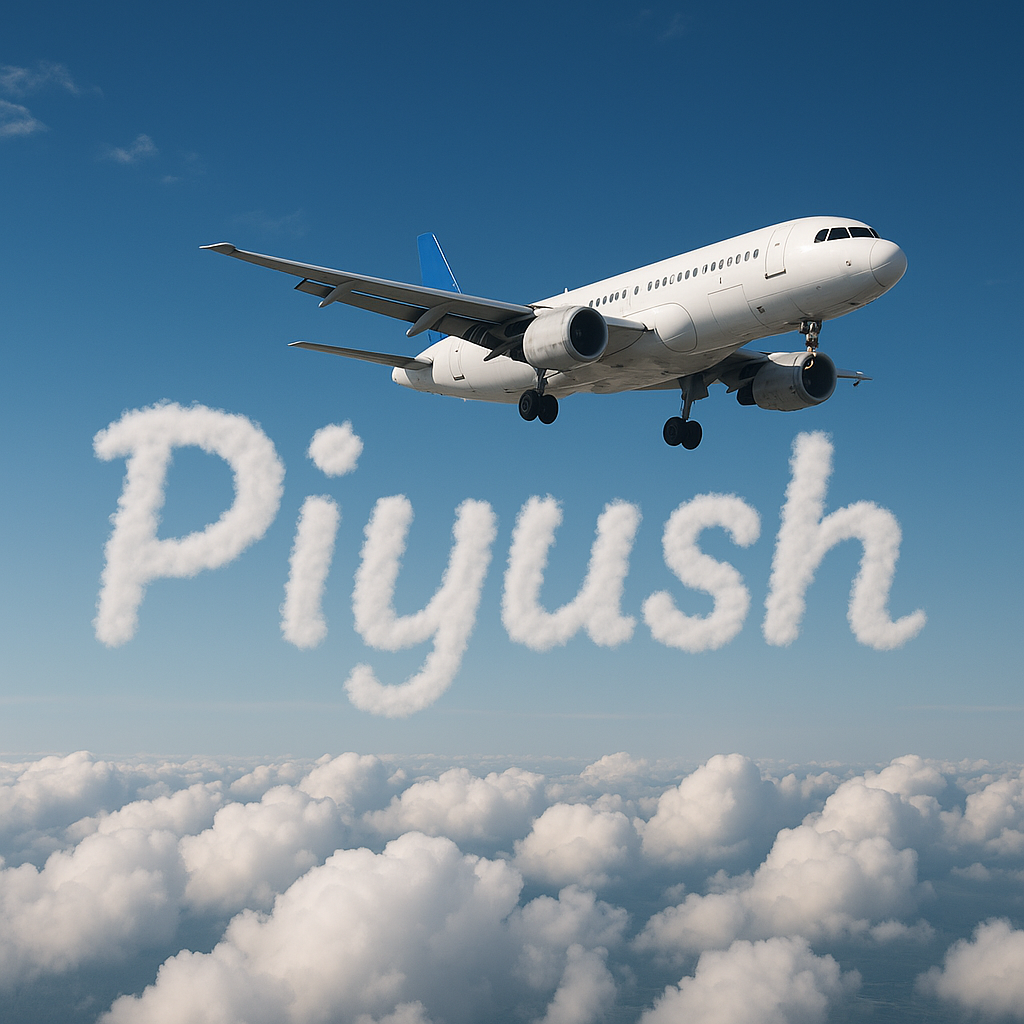

In [37]:
# Image generation

import base64

from IPython.display import Image as ShowImage, display

from meshapi import ImageGenerationParams

IMAGE_MODEL = "openai/gpt-image-1"

img = client.images.generate(
    ImageGenerationParams(prompt="an airplane above a cloud , and its writting Piyush on cloud", model=IMAGE_MODEL, n=1, size="1024x1024", response_format="b64_json")
)

img_bytes = base64.b64decode(img.data[0].b64_json)
with open("generated_airplane.png", "wb") as f:
    f.write(img_bytes)
print(f"Saved generated_airplane.png ({len(img_bytes)} bytes)")
display(ShowImage(img_bytes, width=256))

In [ ]:
# Text to speech
from IPython.display import Audio as ShowAudio

from meshapi import SpeechParams

TTS_MODEL = "hexgrad/kokoro-82m"

speech_bytes = client.audio.synthesize(
    SpeechParams(input="MeshAPI is a gateway for many AI models.", model=TTS_MODEL, voice="af_heart", stream=False)
)

with open("speech.mp3", "wb") as f:
    f.write(speech_bytes)
print(f"Saved speech.mp3 ({len(speech_bytes)} bytes)")
display(ShowAudio("speech.mp3"))

In [39]:
# Moderation
# Checks text (or images) for 13 categories of unsafe content, each with a flag and a confidence score.
from meshapi import ModerationParams

result = client.moderations.create(ModerationParams(input="I want to kill someone"))

r = result.results[0]

print("flagged:", r.flagged)

flagged_categories = {k: v for k, v in r.category_scores.items() if v > 0.1}

print("categories with notable scores:", flagged_categories)

flagged: True
categories with notable scores: {'harassment': 0.3416197214080141, 'harassment/threatening': 0.28511518156125304, 'illicit': 0.16753711744558777, 'violence': 0.9528311271625413}


In [ ]:
#Automatic Retry and fallback
resp = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS,

                    json={"model": FAST_MODEL, "messages": [{"role": "user", "content": "hi"}], "max_tokens": 5})

attempts = resp.headers.get("x-mesh-routing-attempts")

fallback = resp.headers.get("x-mesh-routing-fallback")

print("X-Mesh-Routing-Attempts:", attempts if attempts is not None else "(not sent on this response)")

print("X-Mesh-Routing-Fallback:", fallback if fallback is not None else "(not sent on this response)")

print("These headers show up when MeshAPI's routing logic is exercised -- absent/1-attempt means it just worked.")

In [41]:
# Response Caching

body = {"model": FAST_MODEL, "messages": [{"role": "user", "content": "What is the capital of inida? One word."}], "temperature": 0, "max_tokens": 10}


r1 = requests.post(f"{MESH_API_BASE_URL}/v1/chat/completions", headers=RAWHEADERS, json=body)

print("call 1 -> X-Cache:", r1.headers.get("X-Cache", "(miss, no header)"))


r2 = requests.post(f"{MESH_API_BASE_URL}/v1/chat/completions", headers=RAWHEADERS, json=body)

print("call 2 -> X-Cache:", r2.headers.get("X-Cache", "(miss, no header)"), "  <- free, cached, instant")

call 1 -> X-Cache: (miss, no header)
call 2 -> X-Cache: HIT   <- free, cached, instant


In [42]:
#Prompt template

from meshapi import CreateTemplateParams

template = client.templates.create(CreateTemplateParams(
    name="features-demo-template",
    system="You are a pirate. Speak like one. Company: {{company}}.",
    model=FAST_MODEL,
    variables=["company"],
))

print("created template:", template.id)


resp = client.chat.completions.create(ChatCompletionParams(
    messages=[ChatMessage(role="user", content="Tell me about your services")],
    template=template.id,
    variables={"company": "Acme"},
    max_tokens=60,

))

print(resp.choices[0].message.content)

client.templates.delete(template.id)

print("cleaned up (deleted the demo template)")


created template: 01a090e6-a60d-70d9-9fc3-bf1f1660fa16
Ahoy there, matey! Welcome aboard the Acme ship, where we be providin’ a treasure trove of services for all ye scallywags and landlubbers alike! 

From hearty provisions to keep yer crew fed, to top-notch navigational tools for chartin’ yer
cleaned up (deleted the demo template)


In [43]:
#Web search

from meshapi import WebSearchParams

results = client.web.search(WebSearchParams(query="what is an AI model gateway", max_results=3))

for r in results.results:

    print("-", r.title, "|", r.url)

- AI Gateways and Model Routers, Explained (2026) | https://kilo.ai/articles/ai-gateways-and-model-routers
- What Is an AI Model Gateway Unified Access in a Fast- ... | https://www.tencentcloud.com/techpedia/147959
- AI Gateway & LLM Gateway: How They Work and What ... | https://atlan.com/know/what-is-ai-gateway-llm-gateway/


In [44]:
#Account and balance
resp = requests.get(f"{MESH_API_BASE_URL}/v1/balance", headers=RAWHEADERS)

print(json.dumps(resp.json(), indent=2))

{
  "balance_usd": "0.1852398",
  "reserved_usd": "0.0000000",
  "available_usd": "0.1852398",
  "reserved_breakdown": [],
  "updated_at": "2026-09-11T14:37:40.104245+00:00",
  "message": null
}


In [45]:
resp = requests.get(f"{MESH_API_BASE_URL}/v1/usage/rate-limits", headers=RAWHEADERS)

print("rate limits:", json.dumps(resp.json()["key"], indent=2)[:400])



resp2 = requests.post(f"{MESH_API_BASE_URL}/v1/usage", headers=RAWHEADERS, json={})

print()

print("usage summary attempt -> status", resp2.status_code, "->", resp2.json())

rate limits: {
  "rpm": {
    "current": 0,
    "limit": 100,
    "is_default_limit": true,
    "pct": 0.0,
    "resets_in_seconds": 58
  },
  "rpd": {
    "current": 32,
    "limit": 10000,
    "is_default_limit": true,
    "pct": 0.32,
    "resets_in_seconds": 33657
  },
  "tpm": {
    "current": 0,
    "limit": 1000000,
    "is_default_limit": true,
    "pct": 0.0,
    "resets_in_seconds": 58
  }
}

usage summary attempt -> status 422 -> {'error': {'code': 'validation_error', 'message': 'Request validation failed.', 'details': [{'type': 'missing', 'loc': ['body', 'org_id'], 'msg': 'Field required', 'input': {}}]}, 'request_id': 'req_01M28EGQY0Y2CR57AEGYKCMS59'}
